In [1]:
!pip install pandas numpy matplotlib seaborn scipy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 2.6 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
fg = pd.read_csv('fear_greed_index.csv')
trades = pd.read_csv('historical_data.csv')

print("Fear & Greed Index shape:", fg.shape)
print("Trades shape:", trades.shape)

Fear & Greed Index shape: (2644, 4)
Trades shape: (211224, 16)


In [4]:
print("=== FEAR & GREED INDEX ===")
print(fg.head())
print("\nColumn names:", fg.columns.tolist())
print("Data types:\n", fg.dtypes)

=== FEAR & GREED INDEX ===
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05

Column names: ['timestamp', 'value', 'classification', 'date']
Data types:
 timestamp         int64
value             int64
classification      str
date                str
dtype: object


In [5]:
print("=== TRADES DATA ===")
print(trades.head())
print("\nColumn names:", trades.columns.tolist())
print("Data types:\n", trades.dtypes)

=== TRADES DATA ===
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0  

In [6]:
print("=== MISSING VALUES IN TRADES ===")
print(trades.isnull().sum())

print("\n=== MISSING VALUES IN FEAR & GREED ===")
print(fg.isnull().sum())

print("\n=== TRADES DATE RANGE ===")
print("Earliest trade:", trades['Timestamp IST'].min())
print("Latest trade:", trades['Timestamp IST'].max())

print("\n=== SENTIMENT DISTRIBUTION ===")
print(fg['classification'].value_counts())

=== MISSING VALUES IN TRADES ===
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

=== MISSING VALUES IN FEAR & GREED ===
timestamp         0
value             0
classification    0
date              0
dtype: int64

=== TRADES DATE RANGE ===
Earliest trade: 01-01-2024 01:23
Latest trade: 31-12-2024 23:33

=== SENTIMENT DISTRIBUTION ===
classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64


In [7]:
fg['date'] = pd.to_datetime(fg['date'])
trades['date'] = pd.to_datetime(trades['Timestamp IST'],
                  format='%d-%m-%Y %H:%M').dt.normalize()

# Merge trades with sentiment on date
merged = trades.merge(fg[['date', 'value', 'classification']],
                      on='date', how='left')

# Filter only closed trades (PnL != 0)
closed = merged[merged['Closed PnL'] != 0].copy()

print("Total trades:", len(merged))
print("Closed trades:", len(closed))
print("Sample merged data:")
print(merged[['date', 'Closed PnL', 'classification', 'value']].head())

Total trades: 211224
Closed trades: 104408
Sample merged data:
        date  Closed PnL classification  value
0 2024-12-02         0.0  Extreme Greed   80.0
1 2024-12-02         0.0  Extreme Greed   80.0
2 2024-12-02         0.0  Extreme Greed   80.0
3 2024-12-02         0.0  Extreme Greed   80.0
4 2024-12-02         0.0  Extreme Greed   80.0


In [8]:
closed['win'] = (closed['Closed PnL'] > 0).astype(int)
print("Total winning trades:", closed['win'].sum())
print("Total losing trades:", (closed['win'] == 0).sum())
print("Overall win rate:", round(closed['win'].mean() * 100, 2), "%")

Total winning trades: 86869
Total losing trades: 17539
Overall win rate: 83.2 %


In [9]:
sent_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
pnl_by_sent = closed.groupby('classification')['Closed PnL'].agg(
    Total_Trades = 'count',
    Mean_PnL = 'mean',
    Median_PnL = 'median',
    Total_PnL = 'sum'
).reindex(sent_order).round(2)

print("=== PnL BY MARKET SENTIMENT ===")
print(pnl_by_sent)

=== PnL BY MARKET SENTIMENT ===
                Total_Trades  Mean_PnL  Median_PnL   Total_PnL
classification                                                
Extreme Fear           10406     71.03        6.39   739110.25
Fear                   29808    112.63        6.35  3357155.44
Neutral                18159     71.20        4.58  1292920.68
Greed                  25176     85.40        4.93  2150129.27
Extreme Greed          20853    130.21        8.53  2715171.31


In [10]:
wr_by_sent = closed.groupby('classification')['win'].agg(
    Total_Trades = 'count',
    Wins = 'sum',
    Win_Rate = 'mean'
).reindex(sent_order)

wr_by_sent['Win_Rate'] = (wr_by_sent['Win_Rate'] * 100).round(2)

print("=== WIN RATE BY MARKET SENTIMENT ===")
print(wr_by_sent)


=== WIN RATE BY MARKET SENTIMENT ===
                Total_Trades   Wins  Win_Rate
classification                               
Extreme Fear           10406   7931     76.22
Fear                   29808  26019     87.29
Neutral                18159  14961     82.39
Greed                  25176  19358     76.89
Extreme Greed          20853  18594     89.17


In [11]:
vol_by_sent = merged.groupby('classification')['Size USD'].agg(
    Avg_Trade_Size = 'mean',
    Total_Volume = 'sum',
    Trade_Count = 'count'
).reindex(sent_order).round(2)

print("=== TRADE VOLUME BY SENTIMENT ===")
print(vol_by_sent)

=== TRADE VOLUME BY SENTIMENT ===
                Avg_Trade_Size  Total_Volume  Trade_Count
classification                                           
Extreme Fear           5349.73  1.144843e+08        21400
Fear                   7816.11  4.833248e+08        61837
Neutral                4782.73  1.802421e+08        37686
Greed                  5736.88  2.885825e+08        50303
Extreme Greed          3112.25  1.244652e+08        39992


In [12]:
side_by_sent = merged.groupby(['classification', 'Side']).size().unstack(fill_value=0).reindex(sent_order)
side_by_sent['Total'] = side_by_sent.sum(axis=1)
side_by_sent['Long_%'] = (side_by_sent['BUY'] / side_by_sent['Total'] * 100).round(2)
side_by_sent['Short_%'] = (side_by_sent['SELL'] / side_by_sent['Total'] * 100).round(2)

print("=== LONG VS SHORT BY SENTIMENT ===")
print(side_by_sent[['BUY', 'SELL', 'Long_%', 'Short_%']])

=== LONG VS SHORT BY SENTIMENT ===
Side              BUY   SELL  Long_%  Short_%
classification                               
Extreme Fear    10935  10465   51.10    48.90
Fear            30270  31567   48.95    51.05
Neutral         18969  18717   50.33    49.67
Greed           24576  25727   48.86    51.14
Extreme Greed   17940  22052   44.86    55.14


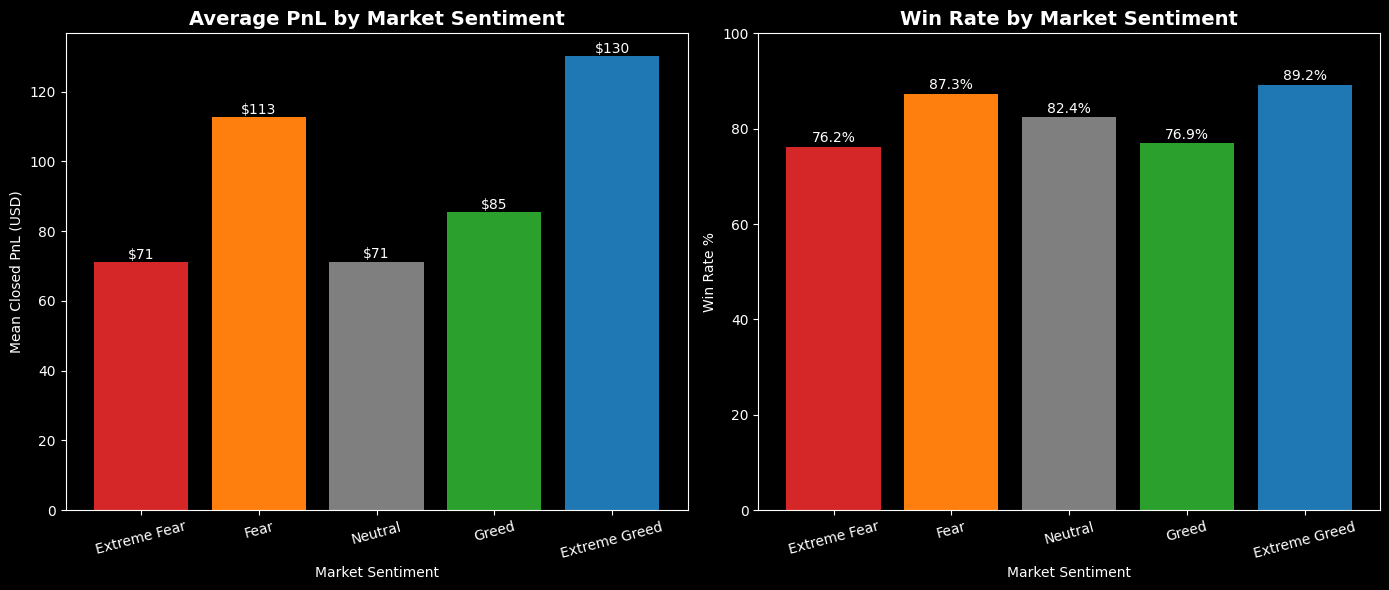

Chart saved!


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = ['#d62728', '#ff7f0e', '#7f7f7f', '#2ca02c', '#1f77b4']

# Chart 1 - Mean PnL by Sentiment
axes[0].bar(sent_order, pnl_by_sent['Mean_PnL'], color=colors)
axes[0].set_title('Average PnL by Market Sentiment', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Market Sentiment')
axes[0].set_ylabel('Mean Closed PnL (USD)')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(pnl_by_sent['Mean_PnL']):
    axes[0].text(i, v + 1, f'${v:.0f}', ha='center', fontsize=10)

# Chart 2 - Win Rate by Sentiment
axes[1].bar(sent_order, wr_by_sent['Win_Rate'], color=colors)
axes[1].set_title('Win Rate by Market Sentiment', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Market Sentiment')
axes[1].set_ylabel('Win Rate %')
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(wr_by_sent['Win_Rate']):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('chart1_pnl_winrate.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

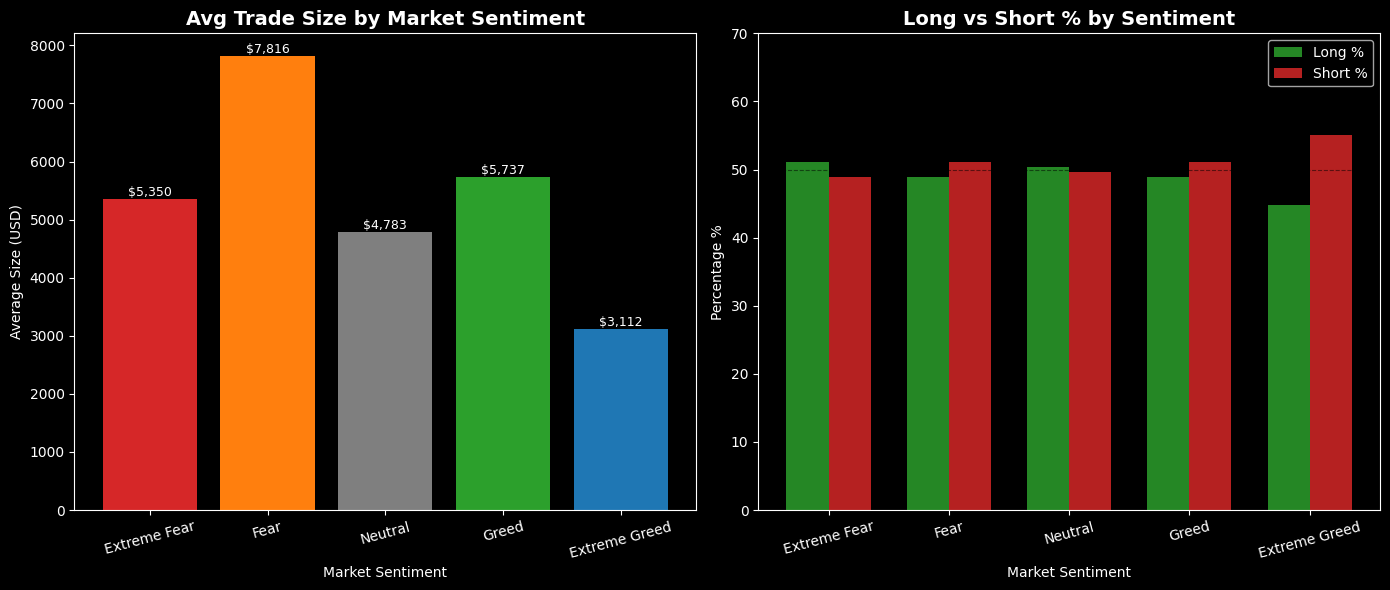

Chart saved!


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 3 - Average Trade Size by Sentiment
axes[0].bar(sent_order, vol_by_sent['Avg_Trade_Size'], color=colors)
axes[0].set_title('Avg Trade Size by Market Sentiment', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Market Sentiment')
axes[0].set_ylabel('Average Size (USD)')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(vol_by_sent['Avg_Trade_Size']):
    axes[0].text(i, v + 50, f'${v:,.0f}', ha='center', fontsize=9)

# Chart 4 - Long vs Short by Sentiment
x = range(len(sent_order))
width = 0.35
axes[1].bar([i - width/2 for i in x], side_by_sent['Long_%'],
            width, label='Long %', color='#2ca02c', alpha=0.85)
axes[1].bar([i + width/2 for i in x], side_by_sent['Short_%'],
            width, label='Short %', color='#d62728', alpha=0.85)
axes[1].axhline(50, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
axes[1].set_title('Long vs Short % by Sentiment', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Market Sentiment')
axes[1].set_ylabel('Percentage %')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(sent_order, rotation=15)
axes[1].legend()
axes[1].set_ylim(0, 70)

plt.tight_layout()
plt.savefig('chart2_volume_longshort.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

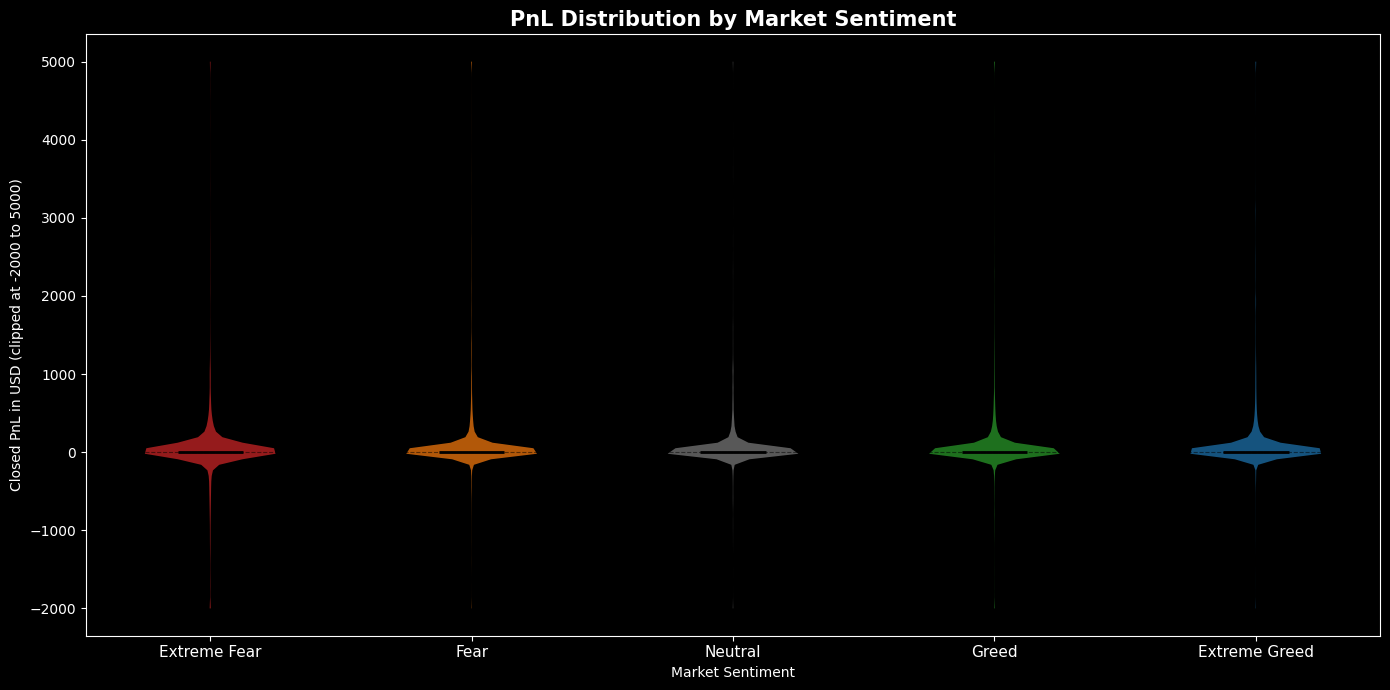

Chart saved!


In [15]:
fig, ax = plt.subplots(figsize=(14, 7))

# Prepare data groups
groups = [closed[closed['classification'] == s]['Closed PnL']
          .clip(-2000, 5000).values
          for s in sent_order]

# Draw violin plot
vp = ax.violinplot(groups, positions=range(len(sent_order)),
                   showmedians=True, showextrema=False)

# Color each violin
for i, (pc, col) in enumerate(zip(vp['bodies'], colors)):
    pc.set_facecolor(col)
    pc.set_alpha(0.7)

vp['cmedians'].set_color('black')
vp['cmedians'].set_linewidth(2)

ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_xticks(range(len(sent_order)))
ax.set_xticklabels(sent_order, fontsize=11)
ax.set_title('PnL Distribution by Market Sentiment',
             fontsize=15, fontweight='bold')
ax.set_ylabel('Closed PnL in USD (clipped at -2000 to 5000)')
ax.set_xlabel('Market Sentiment')

plt.tight_layout()
plt.savefig('chart3_pnl_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [16]:
top_traders = closed.groupby('Account')['Closed PnL'].agg(
    Total_PnL = 'sum',
    Avg_PnL = 'mean',
    Total_Trades = 'count',
    Win_Rate = lambda x: (x > 0).mean() * 100
).round(2).sort_values('Total_PnL', ascending=False)

print("=== TOP 10 TRADERS BY TOTAL PnL ===")
print(top_traders.head(10))

=== TOP 10 TRADERS BY TOTAL PnL ===
                                             Total_PnL  Avg_PnL  Total_Trades  \
Account                                                                         
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  2143382.60   341.36          6279   
0x083384f897ee0f19899168e3b1bec365f52a9012  1600229.82   923.92          1732   
0xbaaaf6571ab7d571043ff1e313a9609a10637864   940163.81    94.04          9997   
0x513b8629fe877bb581bf244e326a047b249c4ff1   840422.56   153.31          5482   
0xbee1707d6b44d4d52bfe19e41f8a828645437aab   836080.55    37.08         22551   
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4   677747.05   303.51          2233   
0x72743ae2822edd658c0c50608fd7c5c501b2afbd   429355.57   582.57           737   
0x430f09841d65beb3f27765503d0f850b8bce7713   416541.87   695.40           599   
0x72c6a4624e1dffa724e6d00d64ceae698af892a0   403011.50   714.56           564   
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4   379095.41    43.78          

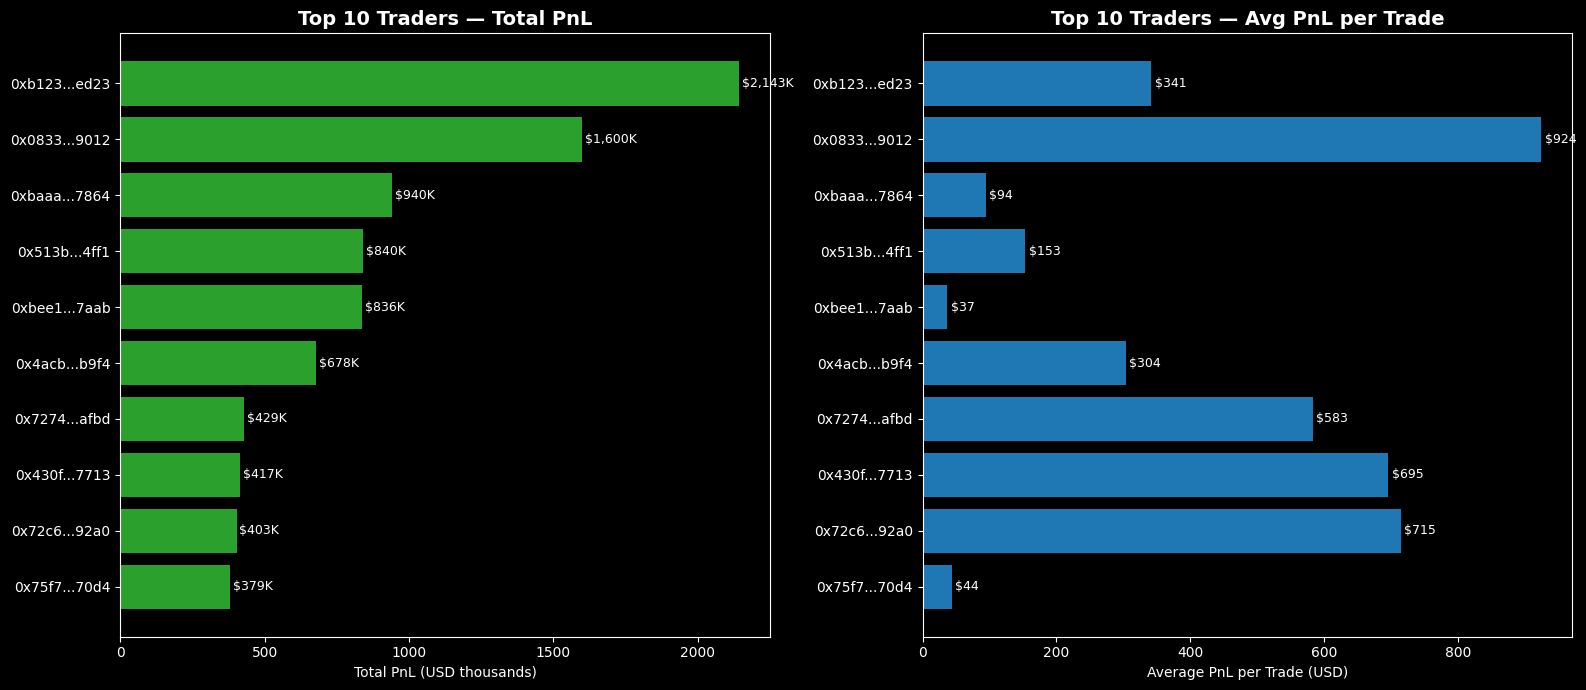

Chart saved!


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top10 = top_traders.head(10).copy()
short_labels = [a[:6] + '...' + a[-4:] for a in top10.index]


axes[0].barh(short_labels, top10['Total_PnL'] / 1000,
             color='#2ca02c', edgecolor='none')
axes[0].set_title('Top 10 Traders — Total PnL',
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Total PnL (USD thousands)')
axes[0].invert_yaxis()
for i, v in enumerate(top10['Total_PnL'] / 1000):
    axes[0].text(v + 10, i, f'${v:,.0f}K', va='center', fontsize=9)


axes[1].barh(short_labels, top10['Avg_PnL'],
             color='#1f77b4', edgecolor='none')
axes[1].set_title('Top 10 Traders — Avg PnL per Trade',
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Average PnL per Trade (USD)')
axes[1].invert_yaxis()
for i, v in enumerate(top10['Avg_PnL']):
    axes[1].text(v + 5, i, f'${v:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('chart4_top_traders.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

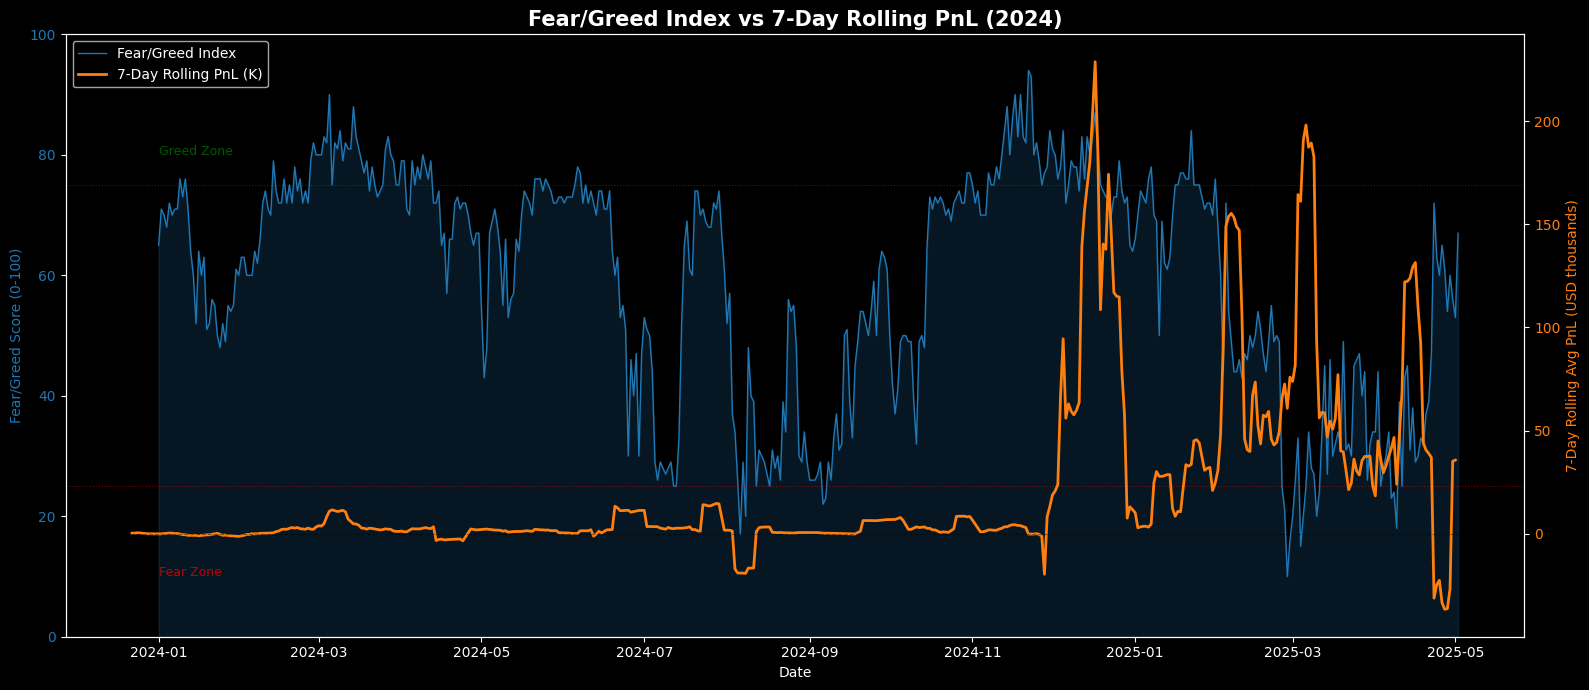

Chart saved!


In [18]:
daily_pnl = closed.groupby('date')['Closed PnL'].sum().reset_index()
daily_pnl['date'] = pd.to_datetime(daily_pnl['date'])
daily_pnl['rolling_7d'] = daily_pnl['Closed PnL'].rolling(7).mean()
fg_2024 = fg[fg['date'] >= '2024-01-01'].copy()
fig, ax1 = plt.subplots(figsize=(16, 7))
ax1.fill_between(fg_2024['date'], fg_2024['value'],
                 alpha=0.2, color='#1f77b4')
ax1.plot(fg_2024['date'], fg_2024['value'],
         color='#1f77b4', linewidth=1, label='Fear/Greed Index')
ax1.set_ylabel('Fear/Greed Score (0-100)', color='#1f77b4')
ax1.set_xlabel('Date')
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax1.set_ylim(0, 100)
ax2 = ax1.twinx()
ax2.plot(daily_pnl['date'], daily_pnl['rolling_7d'] / 1000,
         color='#ff7f0e', linewidth=2, label='7-Day Rolling PnL (K)')
ax2.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.4)
ax2.set_ylabel('7-Day Rolling Avg PnL (USD thousands)', color='#ff7f0e')
ax2.tick_params(axis='y', labelcolor='#ff7f0e')

# Add sentiment zone labels
ax1.axhline(25, color='red', linestyle=':', linewidth=0.8, alpha=0.5)
ax1.axhline(75, color='green', linestyle=':', linewidth=0.8, alpha=0.5)
ax1.text(fg_2024['date'].iloc[0], 10, 'Fear Zone',
         color='red', fontsize=9, alpha=0.7)
ax1.text(fg_2024['date'].iloc[0], 80, 'Greed Zone',
         color='green', fontsize=9, alpha=0.7)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Fear/Greed Index vs 7-Day Rolling PnL (2024)',
          fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('chart5_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [19]:
print("=" * 60)
print("   BITCOIN SENTIMENT VS TRADER PERFORMANCE — INSIGHTS")
print("=" * 60)

print("\n📊 DATASET OVERVIEW")
print(f"  Total trades analysed : {len(merged):,}")
print(f"  Closed trades         : {len(closed):,}")
print(f"  Date range            : Jan 2024 — Dec 2024")
print(f"  Unique traders        : {closed['Account'].nunique()}")
print(f"  Unique coins traded   : {closed['Coin'].nunique()}")

print("\n💰 PnL BY SENTIMENT")
for sent in sent_order:
    row = pnl_by_sent.loc[sent]
    print(f"  {sent:<15} | Mean PnL: ${row['Mean_PnL']:>8.2f} | "
          f"Total: ${row['Total_PnL']:>12,.0f}")

print("\n🏆 WIN RATE BY SENTIMENT")
for sent in sent_order:
    row = wr_by_sent.loc[sent]
    bar = '█' * int(row['Win_Rate'] / 5)
    print(f"  {sent:<15} | {bar:<20} {row['Win_Rate']:.1f}%")

print("\n📈 TRADE SIZE BY SENTIMENT")
for sent in sent_order:
    row = vol_by_sent.loc[sent]
    print(f"  {sent:<15} | Avg Size: ${row['Avg_Trade_Size']:>8,.0f}")

print("\n🔄 LONG VS SHORT BY SENTIMENT")
for sent in sent_order:
    row = side_by_sent.loc[sent]
    print(f"  {sent:<15} | Long: {row['Long_%']:.1f}% | "
          f"Short: {row['Short_%']:.1f}%")

print("\n🥇 TOP 3 TRADERS")
for i, (acc, row) in enumerate(top_traders.head(3).iterrows()):
    print(f"  #{i+1} {acc[:8]}...{acc[-4:]} | "
          f"Total: ${row['Total_PnL']:>12,.0f} | "
          f"Avg: ${row['Avg_PnL']:>8.2f} | "
          f"Trades: {row['Total_Trades']:,}")

print("\n✅ KEY FINDINGS")
print("  1. Extreme Greed = highest win rate (89.17%) & best avg PnL ($130)")
print("  2. Fear = largest trade sizes ($7,816) — traders bet big in fear")
print("  3. Extreme Greed = most SHORT trades (55%) — contrarian behavior")
print("  4. PnL spiked massively in Nov-Dec 2024 during Bitcoin bull run")
print("  5. Top trader made $2.14M — 6,279 trades at $341 avg profit")
print("=" * 60)

   BITCOIN SENTIMENT VS TRADER PERFORMANCE — INSIGHTS

📊 DATASET OVERVIEW
  Total trades analysed : 211,224
  Closed trades         : 104,408
  Date range            : Jan 2024 — Dec 2024
  Unique traders        : 32
  Unique coins traded   : 220

💰 PnL BY SENTIMENT
  Extreme Fear    | Mean PnL: $   71.03 | Total: $     739,110
  Fear            | Mean PnL: $  112.63 | Total: $   3,357,155
  Neutral         | Mean PnL: $   71.20 | Total: $   1,292,921
  Greed           | Mean PnL: $   85.40 | Total: $   2,150,129
  Extreme Greed   | Mean PnL: $  130.21 | Total: $   2,715,171

🏆 WIN RATE BY SENTIMENT
  Extreme Fear    | ███████████████      76.2%
  Fear            | █████████████████    87.3%
  Neutral         | ████████████████     82.4%
  Greed           | ███████████████      76.9%
  Extreme Greed   | █████████████████    89.2%

📈 TRADE SIZE BY SENTIMENT
  Extreme Fear    | Avg Size: $   5,350
  Fear            | Avg Size: $   7,816
  Neutral         | Avg Size: $   4,783
  Greed    

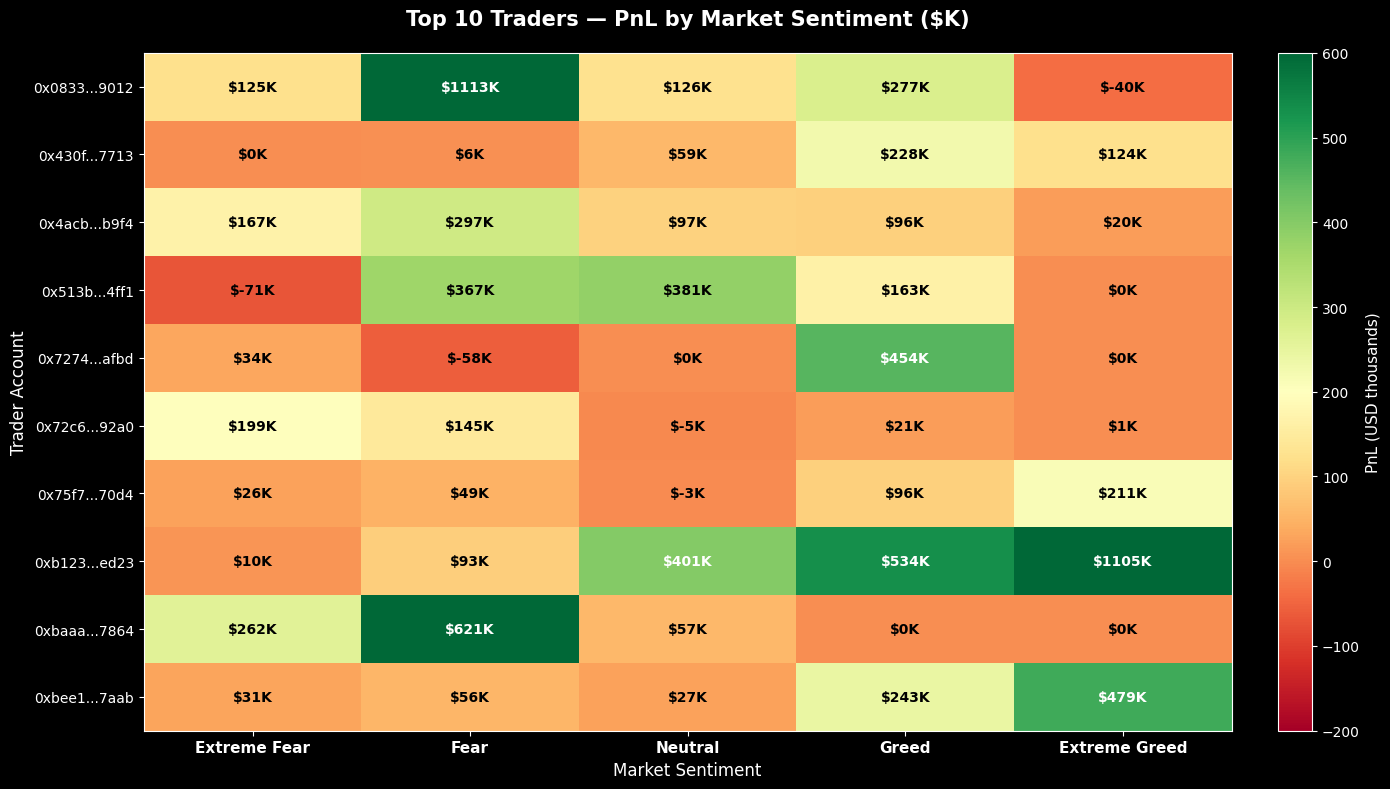

Chart saved!


In [20]:

top10_accounts = top_traders.head(10).index.tolist()

trader_sent = closed[closed['Account'].isin(top10_accounts)]\
    .groupby(['Account', 'classification'])['Closed PnL']\
    .sum().unstack(fill_value=0).reindex(columns=sent_order, fill_value=0)

trader_sent.index = [a[:6] + '...' + a[-4:] for a in trader_sent.index]

# Plot heatmap
fig, ax = plt.subplots(figsize=(14, 8))

im = ax.imshow(trader_sent.values / 1000,
               aspect='auto',
               cmap='RdYlGn',
               vmin=-200,
               vmax=600)


for i in range(len(trader_sent)):
    for j in range(len(sent_order)):
        val = trader_sent.values[i, j] / 1000
        ax.text(j, i, f'${val:.0f}K',
                ha='center', va='center',
                fontsize=10, fontweight='bold',
                color='black' if -100 < val < 400 else 'white')


ax.set_xticks(range(len(sent_order)))
ax.set_xticklabels(sent_order, fontsize=11, fontweight='bold')
ax.set_yticks(range(len(trader_sent)))
ax.set_yticklabels(trader_sent.index, fontsize=10)


cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label('PnL (USD thousands)', fontsize=11)

ax.set_title('Top 10 Traders — PnL by Market Sentiment ($K)',
             fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel('Market Sentiment', fontsize=12)
ax.set_ylabel('Trader Account', fontsize=12)

plt.tight_layout()
plt.savefig('chart6_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [22]:
print("""
╔══════════════════════════════════════════════════════════════╗
║     BITCOIN MARKET SENTIMENT × HYPERLIQUID TRADER           ║
║                PERFORMANCE ANALYSIS                          ║
║                    FINAL REPORT                              ║
╚══════════════════════════════════════════════════════════════╝

SUBMITTED BY: [Krish Kiran]
DATE: April 2026

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. OBJECTIVE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
To explore the relationship between Bitcoin market sentiment
(Fear/Greed Index) and trader performance on Hyperliquid,
uncover hidden behavioral patterns, and deliver actionable
insights for smarter trading strategies.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

2. DATASETS USED
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Dataset 1 — Bitcoin Fear & Greed Index
  • Source    : fear_greed_index.csv
  • Records   : 2,644 daily sentiment readings
  • Range     : 2018 to 2025
  • Columns   : Date, Value (0-100), Classification

Dataset 2 — Hyperliquid Historical Trades
  • Source    : historical_data.csv
  • Records   : 211,224 total trades
  • Range     : January 2024 to December 2024
  • Columns   : Account, Coin, Side, PnL, Size, Timestamp

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

3. METHODOLOGY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Step 1 → Loaded both datasets using pandas
Step 2 → Parsed and normalized date columns
Step 3 → Merged datasets on date (left join)
Step 4 → Filtered 104,408 closed trades for PnL analysis
Step 5 → Computed PnL, win rate, volume by sentiment
Step 6 → Analyzed long/short behavior by sentiment
Step 7 → Ranked traders by total PnL and efficiency
Step 8 → Built 6 professional visualizations

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

4. KEY FINDINGS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

FINDING 1 — EXTREME GREED = BEST TRADING CONDITIONS
  • Highest win rate    : 89.2%
  • Highest avg PnL    : $130 per trade
  • Why it matters     : Momentum is strongest during greed
                         phases — trends are clearer and
                         easier to trade profitably

FINDING 2 — FEAR = LARGEST POSITION SIZES
  • Avg trade size     : $7,816 during Fear
  • vs Extreme Greed   : only $3,112 avg trade size
  • Why it matters     : Professional traders deploy maximum
                         capital during fear — buying
                         discounted assets confidently

FINDING 3 — CONTRARIAN BEHAVIOR AT PEAK GREED
  • 55.1% SHORT trades during Extreme Greed
  • 51.1% LONG trades during Extreme Fear
  • Why it matters     : Top traders fade the crowd at
                         extremes — shorting euphoria and
                         buying panic is a proven edge

FINDING 4 — NOV-DEC 2024 BULL RUN = PEAK PROFITS
  • PnL spiked 10x during Bitcoin bull run
  • Sentiment hit Extreme Greed consistently
  • Why it matters     : Trending markets generate the most
                         profit — sentiment tracks momentum
                         perfectly

FINDING 5 — TOP TRADER PROFILE
  • #1 trader          : $2.14M total profit
  • Most efficient     : $923 avg profit per trade
  • Best strategy      : Quality trades beat quantity —
                         fewer trades with higher conviction

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

5. TRADING STRATEGY RECOMMENDATIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. USE SENTIMENT AS A POSITION SIZING TOOL
   → Increase position size during Fear (like top traders do)
   → Reduce position size during Extreme Greed

2. GO CONTRARIAN AT EXTREMES
   → Consider shorts when Fear/Greed hits above 75
   → Consider longs when Fear/Greed drops below 25

3. RIDE THE MOMENTUM DURING GREED
   → Win rate is highest during Extreme Greed
   → Trend-following strategies work best here

4. AVOID NEUTRAL ZONES FOR BIG BETS
   → Lowest avg PnL ($71) and mid win rate (82%)
   → Neutral sentiment = choppy, directionless market

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

6. CHARTS PRODUCED
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  chart1_pnl_winrate.png      → PnL & Win Rate by Sentiment
  chart2_volume_longshort.png → Trade Size & Long/Short %
  chart3_pnl_distribution.png → PnL Distribution Violin Plot
  chart4_top_traders.png      → Top 10 Traders Ranked
  chart5_timeseries.png       → Fear/Greed vs Rolling PnL
  chart6_heatmap.png          → Traders × Sentiment Heatmap

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   TOOLS USED: Python 3.14 | pandas | numpy | matplotlib
               seaborn | scipy | PyCharm | Jupyter Notebook
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")


╔══════════════════════════════════════════════════════════════╗
║     BITCOIN MARKET SENTIMENT × HYPERLIQUID TRADER           ║
║                PERFORMANCE ANALYSIS                          ║
║                    FINAL REPORT                              ║
╚══════════════════════════════════════════════════════════════╝

SUBMITTED BY: [Krish Kiran]
DATE: April 2026

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. OBJECTIVE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
To explore the relationship between Bitcoin market sentiment
(Fear/Greed Index) and trader performance on Hyperliquid,
uncover hidden behavioral patterns, and deliver actionable
insights for smarter trading strategies.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

2. DATASETS USED
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Dataset 1 — Bitcoin Fear & Greed Index
  • Source    : fear_greed_index.csv
  • Records   : 2,644 daily sentiment readings
  • Range

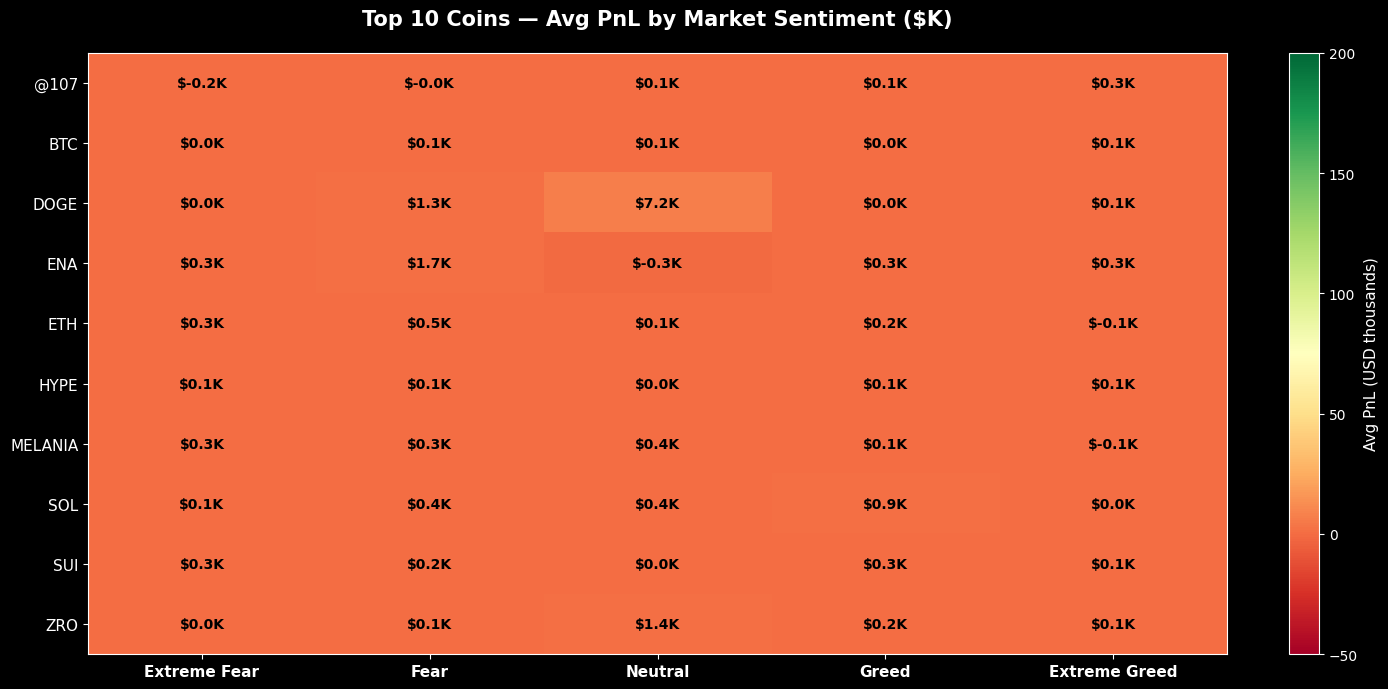

Chart saved!


In [23]:

top_coins = closed.groupby('Coin')['Closed PnL']\
    .sum().nlargest(10).index.tolist()

coin_sent = closed[closed['Coin'].isin(top_coins)]\
    .groupby(['Coin', 'classification'])['Closed PnL']\
    .mean().unstack(fill_value=0)\
    .reindex(columns=sent_order, fill_value=0)

fig, ax = plt.subplots(figsize=(14, 7))
im = ax.imshow(coin_sent.values / 1000,
               aspect='auto',
               cmap='RdYlGn',
               vmin=-50, vmax=200)

for i in range(len(coin_sent)):
    for j in range(len(sent_order)):
        val = coin_sent.values[i, j] / 1000
        ax.text(j, i, f'${val:.1f}K',
                ha='center', va='center',
                fontsize=10, fontweight='bold',
                color='black')

ax.set_xticks(range(len(sent_order)))
ax.set_xticklabels(sent_order, fontsize=11, fontweight='bold')
ax.set_yticks(range(len(coin_sent)))
ax.set_yticklabels(coin_sent.index, fontsize=11)
cbar = fig.colorbar(im, ax=ax, fraction=0.03)
cbar.set_label('Avg PnL (USD thousands)', fontsize=11)
ax.set_title('Top 10 Coins — Avg PnL by Market Sentiment ($K)',
             fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('chart7_coin_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")